# Compare model vs experiment!

2025/04/30

Andrew Weng

In [3]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as patches    

from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the experimental data

In [4]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
# expt2, df2 = ioutils.fetch_experimental_data(152074)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

# Inspect the experimental data

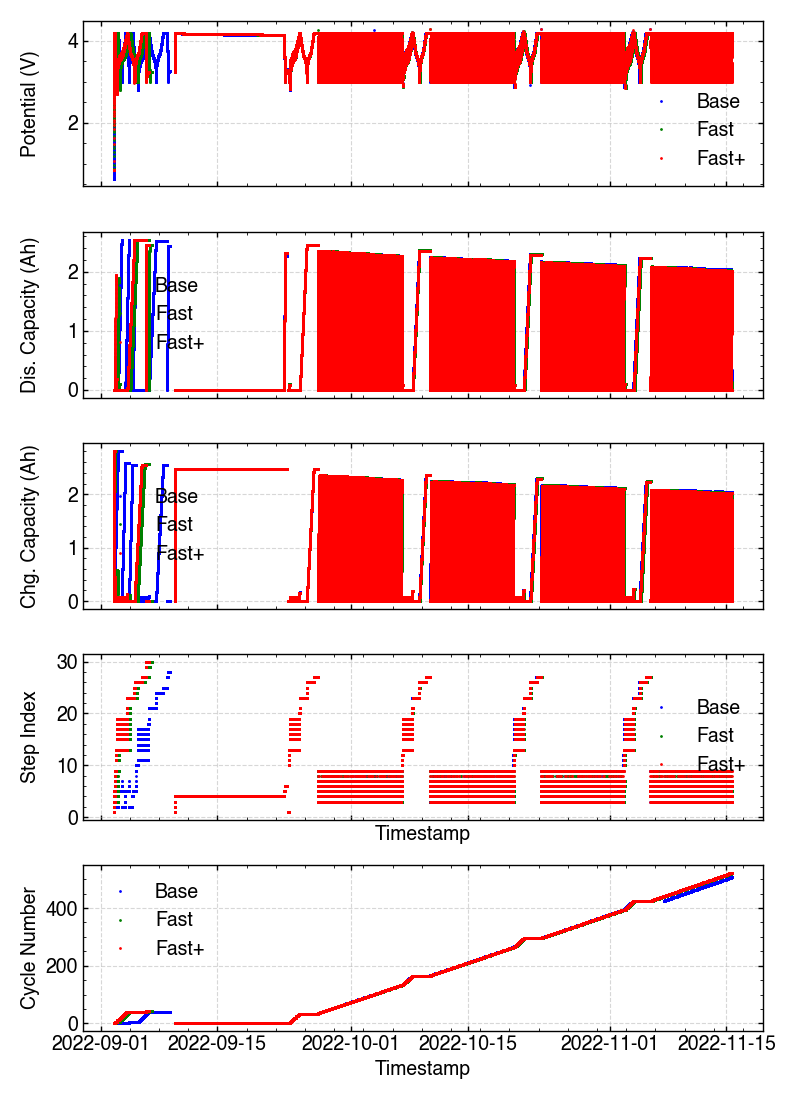

In [5]:
%matplotlib widget

fig, axs = plt.subplots(5, 1, figsize=(8, 11), sharex=True)

xvar = 'Timestamp'
xval1 = df1[xvar]
xval3 = df3[xvar]
xval4 = df4[xvar]

# First subplot
axs[0].plot(xval1, df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(xval3, df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(xval4, df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(xval1, df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(xval3, df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(xval4, df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(xval1, df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(xval3, df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(xval4, df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(xval1, df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(xval3, df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(xval4, df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()

# Fifth suplot (Cycle Number)
axs[4].plot(xval1, df1['Cycle Number'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[4].plot(xval3, df3['Cycle Number'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[4].plot(xval4, df4['Cycle Number'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[4].legend()
axs[4].set_ylabel('Cycle Number')
axs[4].set_xlabel(xvar)
axs[4].grid(True, linestyle='--', alpha=0.5)

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

# Plot the experimental data, nicely

In [6]:
expt1.keys()

# Export arbin data to a CSV file
arbin_data = pd.DataFrame({
    'arbin_time': expt4['arbin_time'],
    'arbin_voltage': expt4['arbin_voltage'],
    'arbin_current': expt4['arbin_current']
})
arbin_data.to_csv('exp4_arbin_data.csv', index=False)

# Export daq data to a CSV file
daq_data = pd.DataFrame({
    'daq_time': expt4['daq_time'],
    'daq_strain': expt4['daq_strain']
})
daq_data.to_csv('exp4_daq_data.csv', index=False)




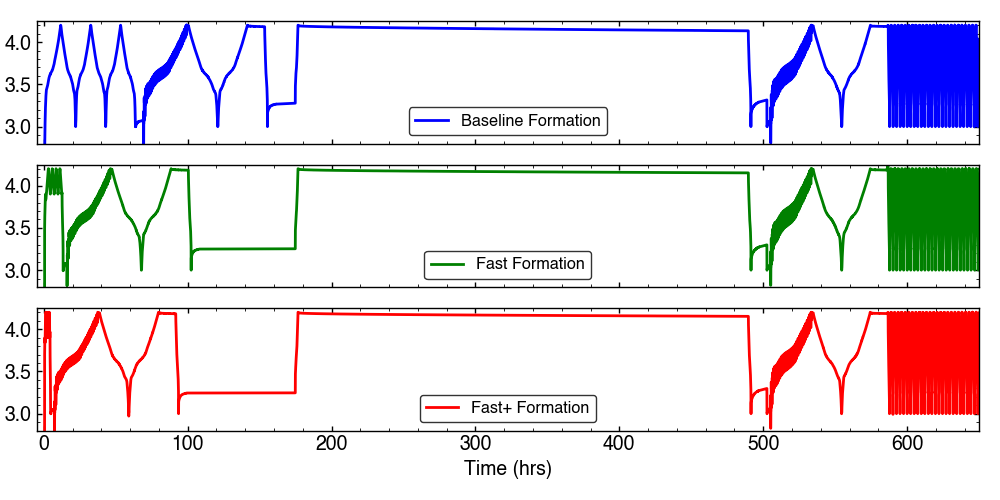

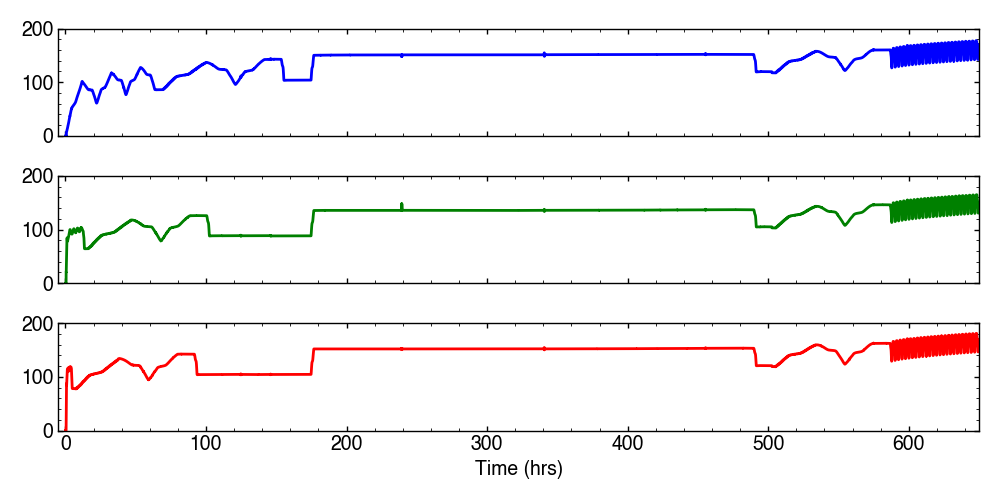

In [7]:
%matplotlib widget 

INCLUDE_INSET = True

ZOOM = 2
match ZOOM:
    case 1:
        XLIM_INSET = (0, 10)
        XMAX = 500
        STRAIN_LIM = (0, 160)
        STRAIN_LIM_INSET = (0, 130)
    case 2:        
        XLIM_INSET = (550, 650)
        XMAX = 650
        STRAIN_LIM = (0, 200)
        STRAIN_LIM_INSET = (100, 285)

FIGSIZE = (10, 5)

## VOLTAGE PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True, sharey=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline Formation', color='b', ls='-')
# axs[0].set_ylabel('Potential (V)')
axs[0].grid(False)
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')
axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast Formation', color='g', ls='-')
# axs[1].set_ylabel('Potential (V)')
axs[1].grid(False)
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')
axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+ Formation', color='r', ls='-')
# axs[2].set_ylabel('Potential (V)')

axs[0].legend(loc='lower center', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[1].legend(loc='lower center', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[2].legend(loc='lower center', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')


axs[2].grid(False)
axs[2].set_xlim(-5, XMAX)
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')
axs[2].set_ylim((2.8, 4.25))
axs[2].set_xlabel('Time (hrs)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig(f'experimental_voltage_{XMAX}h.svg', format='svg', dpi=300)
plt.show()


## STRAIN PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True, sharey=True)

axs[0].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline Formation', color='b', ls='-', marker='', markersize=1)
# axs[0].set_ylabel('Expansion (µm)')
axs[0].grid(False)
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')
# axs[0].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
# axs[0].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.06, 0.02))

axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast Formation', color='g', ls='-', marker='', markersize=1)
# axs[1].set_ylabel('Expansion (µm)')
axs[1].grid(False)
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')
# axs[1].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
# axs[1].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.06, 0.02))

axs[2].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+ Formation', color='r', ls='-', marker='', markersize=1)
# axs[2].set_ylabel('Expansion (µm)')
axs[2].set_ylim(STRAIN_LIM)
axs[2].grid(False)
axs[2].set_xlim((-5, XMAX))
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')
# axs[2].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
# axs[2].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.06, 0.02))

# axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Base', color='blue', ls='', marker='o', markersize=1)
# axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='green', ls='', marker='o', markersize=1)
# axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red', ls='', marker='o', markersize=1)
# axs[1].set_ylabel('Strain (um)')
# axs[1].legend()

axs[2].set_xlabel('Time (hrs)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig(f'experimental_strain_{XMAX}h.svg', format='svg', dpi=300)
plt.show()

# Set up and run the simulations

In [8]:
# With optimal d_ec and d_vc values
# Trial 0
# d_ec_opt1 = 3.2e-20  # Optimal d_ec for base
# d_vc_opt1 = 4.2e-16  # Optimal d_vc for base
# d_ec_opt2 = 3.2e-20  # Optimal d_ec for fast
# d_vc_opt2 = 3.2e-17  # Optimal d_vc for fast
# d_ec_opt3 = 5.1e-20  # Optimal d_ec for fast+
# d_vc_opt3 = 3.2e-17  # Optimal d_vc for fast+
# d_ec_b = 4.2e-20  # Baseline d_ec from Weng2023
# d_vc_b = 6.6e-18  # Baseline d_vc from Weng2023
# d_ec_opt = 2.84e-20
# d_vc_opt = 5.39e-14
# gamma_kappa = 3367 * 2

# Trial 1??
d_ec_opt1 = 3.665e-20
d_vc_opt1 = 3.162e-17
d_ec_opt2 = 2.7e-20
d_vc_opt2 = 5.3e-17
d_ec_opt3 = 4.924e-20
d_vc_opt3 = 3.162e-17


# d_vc_opt = 6.14664e-14
# d_ec_opt = 4.5185e-20

# Trial 2??
# d_ec_opt1 = 5.109e-20
# d_vc_opt1 = 9.120e-18
# d_ec_opt2 = 2.0e-20
# d_vc_opt2 = 2.5e-16
# d_ec_opt3 = 5.109e-20
# d_vc_opt3 = 1.096e-16

d_ec_b = d_ec_opt1
d_vc_b = d_vc_opt1

In [20]:
# df_sim1 = run_sim('base', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp1)
# df_sim2 = run_sim('fast', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp3)
# df_sim3 = run_sim('fast+', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp4)

# With optimized d_ec and d_vc values
df_sim1o = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, kappa_ec=1.415e-4, kappa_vc=3.10e-5, dt=5, include_flag=5, dsei_derating_cycling=1e-1)
df_sim2o = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, kappa_ec=1.797e-4, kappa_vc=3.10e-5, dt=5, include_flag=5, dsei_derating_cycling=1e-1)
df_sim3o = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, kappa_ec=2.559e-4, kappa_vc=3.10e-5, dt=1, include_flag=5, dsei_derating_cycling=1e-1)

# df_sim1o = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, dt=5, include_flag=5, dsei_derating_cycling=1e-1)
# df_sim2o = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, dt=5, include_flag=5, dsei_derating_cycling=1e-1)
# df_sim3o = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, dt=1, include_flag=5, dsei_derating_cycling=1e-1)

# With baseline d_ec and d_vc values 
df_sim1 = simutils.run_sim('base', d_ec_b, d_vc_b, dt=5, include_flag=5, dsei_derating_cycling=1e-1)
df_sim2 = simutils.run_sim('fast', d_ec_b, d_vc_b, dt=5, include_flag=5, dsei_derating_cycling=1e-1)
df_sim3 = simutils.run_sim('fast+', d_ec_b, d_vc_b, dt=1, include_flag=5, dsei_derating_cycling=1e-1)

# Optimize resistance from first RPT
# kappa_vc = 3.10e-5
# df_sim1 = simutils.run_sim('base', d_ec_b, d_vc_b, kappa_ec=1.492e-4, kappa_vc=kappa_vc, dt=5, include_flag=4)
# df_sim2 = simutils.run_sim('fast', d_ec_b, d_vc_b, kappa_ec=1.797e-4, kappa_vc=kappa_vc, dt=5, include_flag=4)
# df_sim3 = simutils.run_sim('fast+', d_ec_b, d_vc_b, kappa_ec=2.864e-4, kappa_vc=kappa_vc, dt=1, include_flag=4)

# df_sim1 = simutils.run_sim('base', d_ec_b, d_vc_b, kappa_ec=4.771e-4, kappa_vc=2.050e-5, dt=5, include_flag=4)
# df_sim2 = simutils.run_sim('fast', d_ec_b, d_vc_b, kappa_ec=2.3e-4, kappa_vc=4.0e-5, dt=5, include_flag=4)
# df_sim3 = simutils.run_sim('fast+', d_ec_b, d_vc_b, kappa_ec=1.949e-4, kappa_vc=5.5e-5, dt=1, include_flag=4)


# Optimize resistance from both RPTs
# kappa_ec = 5e-6
# kappa_vc = 1.9e-5
# df_sim1 = simutils.run_sim('base', d_ec_b, d_vc_b, kappa_ec=kappa_ec, kappa_vc=kappa_vc, dt=5, include_flag=4)
# df_sim2 = simutils.run_sim('fast', d_ec_b, d_vc_b, kappa_ec=kappa_ec, kappa_vc=kappa_vc, dt=5, include_flag=4)
# df_sim3 = simutils.run_sim('fast+', d_ec_b, d_vc_b, kappa_ec=kappa_ec, kappa_vc=kappa_vc, dt=1, include_flag=4)


# df_sim1 = simutils.run_sim('base', d_ec_b, d_vc_b, dt=5, include_flag=4)
# df_sim2 = simutils.run_sim('fast', d_ec_b, d_vc_b, dt=5, include_flag=4)
# df_sim3 = simutils.run_sim('fast+', d_ec_b, d_vc_b, dt=1, include_flag=4)


# With baseline d_ec and d_vc values from the recent parameter sensitivity study (it yielded some different values because we 
# explicitly ran search for the optimal values instead of "eyeballing it" as we did for Weng2023; it makes a big difference in some metrics 
# like VC concentration; it makes less of a difference for other metrics like voltage fit).
# df_sim1 = simutils.run_sim('base', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True)
# df_sim2 = simutils.run_sim('fast', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True)
# df_sim3 = simutils.run_sim('fast+', 3.2e-20, 4.2e-16, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True)

# Plot model vs experiment

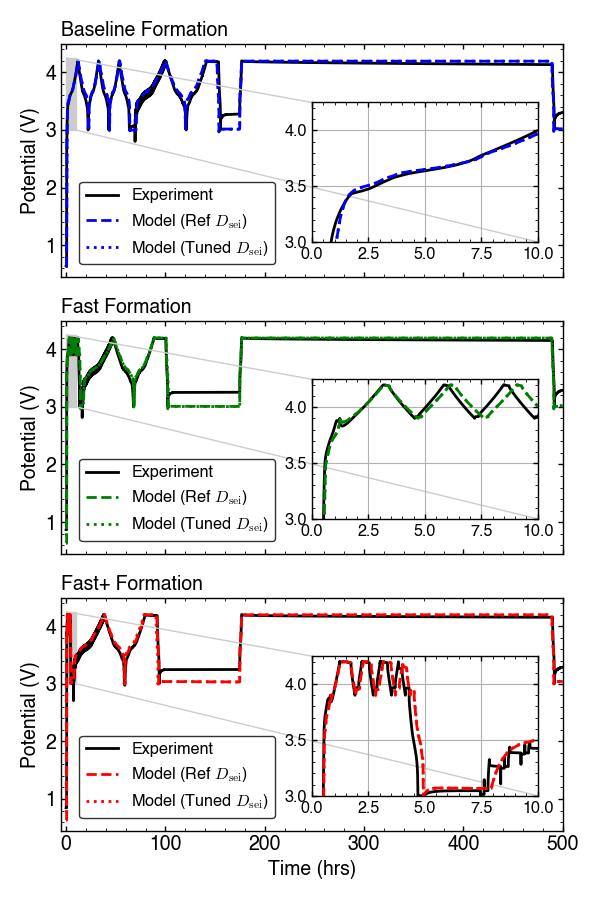

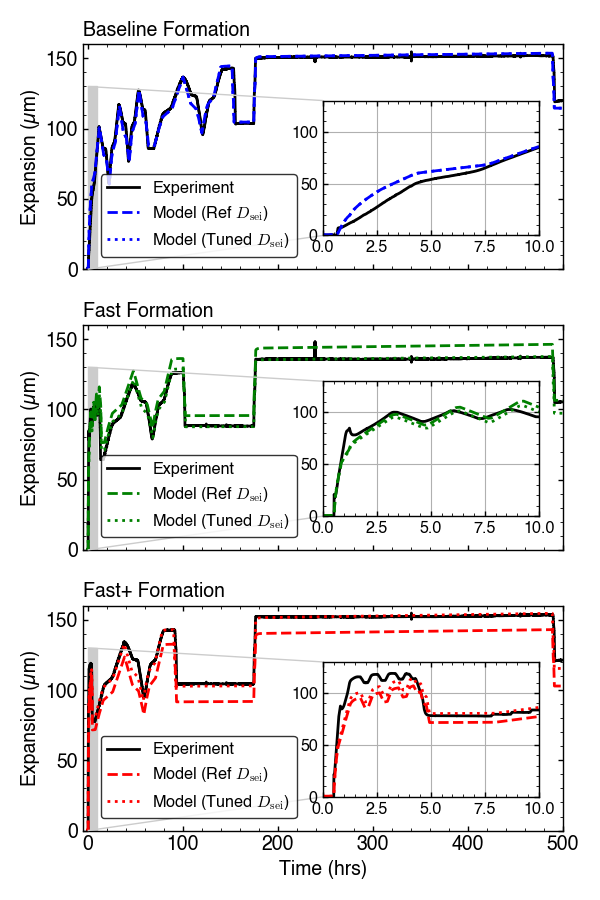

In [10]:
%matplotlib widget 

INCLUDE_INSET = True

ZOOM = 1
match ZOOM:
    case 1:
        XLIM_INSET = (0, 10)
        XMAX = 500
        STRAIN_LIM = (0, 160)
        STRAIN_LIM_INSET = (0, 130)
    case 2:        
        XLIM_INSET = (550, 650)
        XMAX = 800
        STRAIN_LIM = (0, 310)
        STRAIN_LIM_INSET = (100, 285)

FIGSIZE = (6, 9)

## VOLTAGE PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True, sharey=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Experiment', color='k', ls='-')
axs[0].plot(df_sim1['t']/3600, df_sim1['vt'], label=r'Model (Ref $D_{\mathrm{sei}}$)', color='blue', ls='--')
axs[0].plot(df_sim1o['t']/3600, df_sim1o['vt'], label=r'Model (Tuned $D_{\mathrm{sei}}$)', color='blue', ls=':')
axs[0].set_ylabel('Potential (V)')
axs[0].grid(False)
axs[0].set_title('Baseline Formation', loc='left', fontsize='medium')
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')
axs[0].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))

axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Experiment', color='k', ls='-')
axs[1].plot(df_sim2['t']/3600, df_sim2['vt'], label=r'Model (Ref $D_{\mathrm{sei}}$)', color='green', ls='--')
axs[1].plot(df_sim2o['t']/3600, df_sim2o['vt'], label=r'Model (Tuned $D_{\mathrm{sei}}$)', color='green', ls=':')
axs[1].set_ylabel('Potential (V)')
axs[1].grid(False)
axs[1].set_title('Fast Formation', loc='left', fontsize='medium')
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')
axs[1].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))

axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Experiment', color='k', ls='-')
axs[2].plot(df_sim3['t']/3600, df_sim3['vt'], label=r'Model (Ref $D_{\mathrm{sei}}$)', color='red', ls='--')
axs[2].plot(df_sim3o['t']/3600, df_sim3o['vt'], label=r'Model (Tuned $D_{\mathrm{sei}}$)', color='red', ls=':')
axs[2].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))
axs[2].set_ylabel('Potential (V)')
axs[2].grid(False)
axs[2].set_xlim(-5, XMAX)
axs[2].set_title('Fast+ Formation', loc='left', fontsize='medium')
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

if INCLUDE_INSET:
    # Create insets for each subplot
    axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

    # Plot the zoomed regions
    axins1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k')
    axins1.plot(df_sim1['t']/3600, df_sim1['vt'], color='blue', ls='--')
    axins1.plot(df_sim1o['t']/3600, df_sim1o['vt'], color='blue', ls=':')
    axins2.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='k')
    axins2.plot(df_sim2['t']/3600, df_sim2['vt'], color='green', ls='--')
    axins2.plot(df_sim2o['t']/3600, df_sim2o['vt'], color='green', ls=':')
    axins3.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='k')
    axins3.plot(df_sim3['t']/3600, df_sim3['vt'], color='red', ls='--')
    axins3.plot(df_sim3o['t']/3600, df_sim3o['vt'], color='red', ls=':')

    # Set the limits for the zoomed region (first 10 hours)
    for axins in [axins1, axins2, axins3]:
        axins.set_xlim(XLIM_INSET)
        axins.set_ylim(3, 4.25)
        axins.tick_params(axis='both', labelsize='small')
        # axins.grid(False)

    # Mark the inset regions
    mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

axs[2].set_xlabel('Time (hrs)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig(f'outputs/figures/experimental_voltage_{XMAX}h.svg', format='svg', dpi=300)
plt.show()


## STRAIN PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True, sharey=True)

axs[0].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Experiment', color='k', ls='-', marker='', markersize=1)
axs[0].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, label=r'Model (Ref $D_{\mathrm{sei}}$)', color='blue', ls='--')
axs[0].plot(df_sim1o['t']/3600, df_sim1o['expansion']*1e6, label=r'Model (Tuned $D_{\mathrm{sei}}$)', color='blue', ls=':')
axs[0].set_ylabel('Expansion (µm)')
axs[0].grid(False)
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')
axs[0].set_title('Baseline Formation', loc='left', fontsize='medium')
# axs[0].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[0].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))

axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Experiment', color='k', ls='-', marker='', markersize=1)
axs[1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, label=r'Model (Ref $D_{\mathrm{sei}}$)', color='green', ls='--')
axs[1].plot(df_sim2o['t']/3600, df_sim2o['expansion']*1e6, label=r'Model (Tuned $D_{\mathrm{sei}}$)', color='green', ls=':')
axs[1].set_ylabel('Expansion (µm)')
axs[1].grid(False)
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')
axs[1].set_title('Fast Formation', loc='left', fontsize='medium')
# axs[1].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[1].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))

axs[2].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Experiment', color='k', ls='-', marker='', markersize=1)
axs[2].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, label=r'Model (Ref $D_{\mathrm{sei}}$)', color='red', ls='--')
axs[2].plot(df_sim3o['t']/3600, df_sim3o['expansion']*1e6, label=r'Model (Tuned $D_{\mathrm{sei}}$)', color='red', ls=':')
axs[2].set_ylabel('Expansion (µm)')
axs[2].set_ylim(STRAIN_LIM)
axs[2].grid(False)
axs[2].set_xlim((-5, XMAX))
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')
axs[2].set_title('Fast+ Formation', loc='left', fontsize='medium')
# axs[2].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[2].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))

if INCLUDE_INSET:
    # Create insets for each subplot
    axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

    # Plot the zoomed regions
    axins1.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k')
    axins1.plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='blue', ls='--')
    axins1.plot(df_sim1o['t']/3600, df_sim1o['expansion']*1e6, color='blue', ls=':')
    axins2.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='k')
    axins2.plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='green', ls='--')
    axins2.plot(df_sim2o['t']/3600, df_sim2o['expansion']*1e6, color='green', ls=':')
    axins3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='k')
    axins3.plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='red', ls='--')
    axins3.plot(df_sim3o['t']/3600, df_sim3o['expansion']*1e6, color='red', ls=':')

    # Set the limits for the zoomed region (first 10 hours)
    for axins in [axins1, axins2, axins3]:
        axins.set_xlim(XLIM_INSET)
        # axins.set_ylim(-5, 130)
        axins.tick_params(axis='both', labelsize='small')
        axins.set_ylim(STRAIN_LIM_INSET)
        axins.grid(True)

    # Mark the inset regions
    mark_inset(axs[0], axins1, loc1=2, loc2=3, fc="0.8", ec="0.8")
    mark_inset(axs[1], axins2, loc1=2, loc2=3, fc="0.8", ec="0.8")
    mark_inset(axs[2], axins3, loc1=2, loc2=3, fc="0.8", ec="0.8")

# axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Base', color='blue', ls='', marker='o', markersize=1)
# axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='green', ls='', marker='o', markersize=1)
# axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red', ls='', marker='o', markersize=1)
# axs[1].set_ylabel('Strain (um)')
# axs[1].legend()

axs[2].set_xlabel('Time (hrs)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig(f'outputs/figures/experimental_strain_{XMAX}h.svg', format='svg', dpi=300)
plt.show()

# ## CURRENT PLOTS

# fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

# axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_current'], label='Baseline Formation', color='blue', ls='-')
# axs[0].plot(df_sim1['t']/3600, df_sim1['i_app'], label='Simulated', color='blue', ls='--')
# axs[0].set_ylabel('Current (A)')
# axs[0].grid(False)
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

# axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_current'], label='Fast Formation', color='green', ls='-')
# axs[1].plot(df_sim2['t']/3600, df_sim2['i_app'], label='Simulated', color='green', ls='--')
# axs[1].set_ylabel('Current (A)')
# axs[1].grid(False)
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

# axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_current'], label='Fast+ Formation', color='red', ls='-')
# axs[2].plot(df_sim3['t']/3600, df_sim3['i_app'], label='Simulated', color='red', ls='--')
# axs[2].set_ylabel('Current (A)')
# axs[2].grid(False)
# axs[2].set_xlim((-5, XMAX))
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# axs[2].set_xlabel('Test Time (h)')


# if INCLUDE_INSET:
#     # Create insets for each subplot
#     axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
#     axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
#     axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

#     # Plot the zoomed regions
#     axins1.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='blue')
#     axins1.plot(df_sim1['t']/3600, df_sim1['i_app'], color='blue', ls='--')
#     axins2.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='green')
#     axins2.plot(df_sim2['t']/3600, df_sim2['i_app'], color='green', ls='--')
#     axins3.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='red')
#     axins3.plot(df_sim3['t']/3600, df_sim3['i_app'], color='red', ls='--')

#     # Set the limits for the zoomed region (first 10 hours)
#     for axins in [axins1, axins2, axins3]:
#         axins.set_xlim(XLIM_INSET)
#         axins.grid(True)

# fig.align_ylabels(axs)
# plt.tight_layout()
# plt.savefig('experimental_current.svg', format='svg', dpi=300)
# plt.show()

# Compare model vs experiment: overlay 

In [ ]:
# Set some constants
rho_vc = 1.3
rho_ec = 1.6

# Initial cell capacities 
Q01 = 2.88633
Q02 = 2.88633
Q03 = 2.88633

# Manually extracted capacity values from the experimental data
# During the formation cycling
qc_base_1_time = 0.53*3600 
qc_base_1_val  = 2.81
qc_base_2_time = 22.3*3600
qc_base_2_val  = 2.58
qc_base_3_time = 43.2*3600
qc_base_3_val  = 2.55

qd_base_1_time = 11.9*3600 
qd_base_1_val  = 2.546
qd_base_2_time = 32.8*3600
qd_base_2_val  = 2.545
qd_base_3_time = 53.6*3600
qd_base_3_val  = 2.530

# RPT after formation cycling
qd_base_rpt1_time = 100.6 * 3600
qd_base_rpt1_val  = 2.53
qd_fast_rpt1_time = 47.5 * 3600
qd_fast_rpt1_val  = 2.54
qd_fastp_rpt1_time = 38.7 * 3600
qd_fastp_rpt1_val  = 2.54

# RPT after formation aging
qd_base_rpt2_time = 534.8 * 3600
qd_base_rpt2_val  = 2.46
qd_fast_rpt2_time = 534.8 * 3600
qd_fast_rpt2_val  = 2.46
qd_fastp_rpt2_time = 534.8 * 3600
qd_fastp_rpt2_val  = 2.46

# SEI resistance
rs_meas1_base = 21.5e-3 
rs_meas1_fast = 17.7e-3
rs_meas1_fast_plus = 16.6e-3 

t_hppc1_base = 69.39*3600
t_hppc1_fast = 16.17*3600
t_hppc1_fast_plus = 7.465*3600
rs_meas1_time_base = t_hppc1_base + 54000
rs_meas1_time_fast = t_hppc1_fast + 54000
rs_meas1_time_fast_plus = t_hppc1_fast_plus + 54000
rs_meas2_time = 505.23 * 3600 + 5e4
rs_meas2_base = 0.0375
rs_meas2_fast = 0.0366
rs_meas2_fast_plus = 0.0366

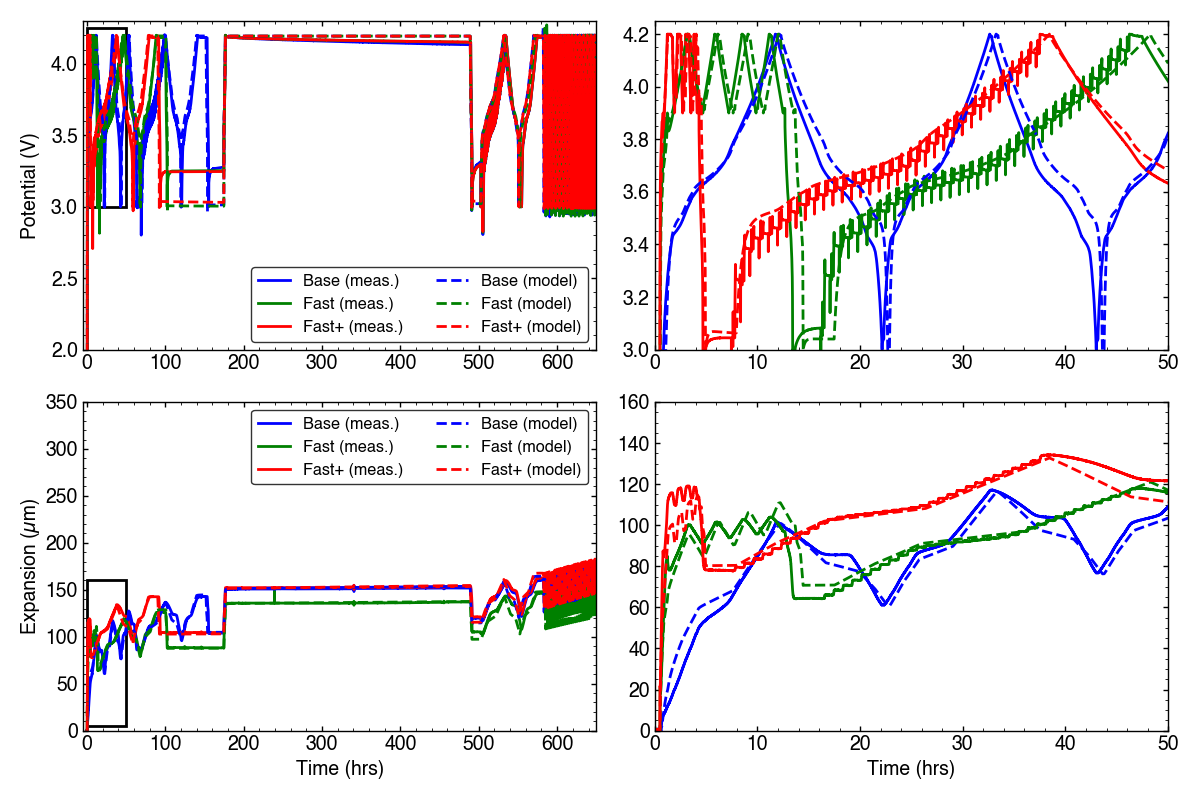

In [27]:
df_sim1 = df_sim1o
df_sim2 = df_sim2o
df_sim3 = df_sim3o

XMAX = 650;

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

# First subplot - Voltage
axs[0,0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='b', label='Base (meas.)')
axs[0,0].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='g', label='Fast (meas.)')
axs[0,0].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+ (meas.)')
axs[0,0].plot(df_sim1['t']/3600, df_sim1['vt'], color='b', ls='--', label='Base (model)')
axs[0,0].plot(df_sim2['t']/3600, df_sim2['vt'], color='g', ls='--', label='Fast (model)')
axs[0,0].plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='Fast+ (model)')
axs[0,0].legend(loc='lower right', ncols=2, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[0,0].set_ylabel('Potential (V)')
axs[0,0].grid(False)
axs[0,0].set_xlim(-5, XMAX)
axs[0,0].set_ylim(2.0, 4.30)
axs[0,0].add_patch(patches.Rectangle((0, 3.0), 50, 4.25-3.0, linewidth=2, edgecolor='k', facecolor='none'))

# Plot the same voltage data in the inset
axs[0,1].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='b')
axs[0,1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='g')
axs[0,1].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r')
axs[0,1].plot(df_sim1['t']/3600, df_sim1['vt'], color='b', ls='--')
axs[0,1].plot(df_sim2['t']/3600, df_sim2['vt'], color='g', ls='--')
axs[0,1].plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--')
axs[0,1].set_xlim(0, 50)
axs[0,1].set_ylim((3.0, 4.25))
axs[0,1].grid(False)

axs[1,0].plot(expt1['daq_time']/3600, expt1['daq_strain'], color='b', label='Base (meas.)', ls='-')
axs[1,0].plot(expt3['daq_time']/3600, expt3['daq_strain'], color='g', label='Fast (meas.)', ls='-')
axs[1,0].plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+ (meas.)', ls='-')
axs[1,0].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='b', label='Base (model)', ls='--')
axs[1,0].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='g', label='Fast (model)', ls='--')
axs[1,0].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='r', label='Fast+ (model)', ls='--')
axs[1,0].set_ylabel(r'Expansion (µm)')
axs[1,0].set_ylim((0, 220))
axs[1,0].set_xlim(-5, XMAX)
axs[1,0].legend(loc='upper right', ncols=2, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[1,0].grid(False)
axs[1,0].set_ylim(0, 350)
axs[1,0].set_xlabel('Time (hrs)')
axs[1,0].add_patch(patches.Rectangle((0, 5), 50, 160-5, linewidth=2, edgecolor='k', facecolor='none'))


# Plot the same strain data in the inset
axs[1,1].plot(expt1['daq_time']/3600, expt1['daq_strain'], color='b')
axs[1,1].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='b', ls='--')
axs[1,1].plot(expt3['daq_time']/3600, expt3['daq_strain'], color='g')
axs[1,1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='g', ls='--')
axs[1,1].plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r')
axs[1,1].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='r', ls='--')
axs[1,1].set_xlim(0, 50)
axs[1,1].set_ylim((0, 160))
axs[1,1].grid(False)
axs[1,1].set_xlabel('Time (hrs)')

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()

plt.savefig('outputs/figures/experimental_vs_simulated_combined_global_dsei.svg', format='svg', dpi=300)

# Resistance and Capacity

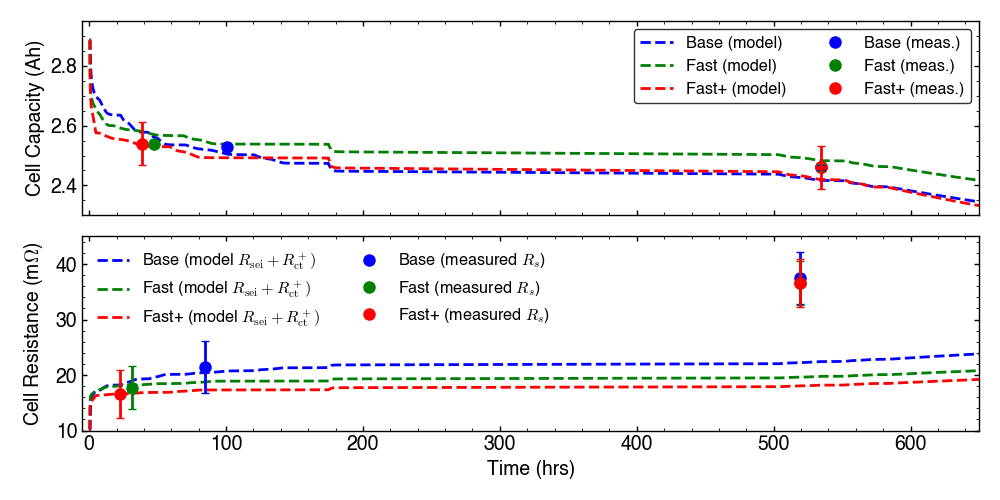

In [ ]:
XMAX = 650;

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)


axs[0].plot(df_sim1['t']/3600, Q01 - df_sim1['q_sei'], color='b', label='Base (model)', ls='--')
axs[0].plot(df_sim2['t']/3600, Q02 - df_sim2['q_sei'], color='g', label='Fast (model)', ls='--')
axs[0].plot(df_sim3['t']/3600, Q03 - df_sim3['q_sei'], color='r', label='Fast+ (model)', ls='--')


# Draw error bars for each marker

axs[0].plot(qd_base_rpt1_time/3600, qd_base_rpt1_val, 'bo', markersize=8, label='Base (meas.)')
axs[0].plot(qd_fast_rpt1_time/3600, qd_fast_rpt1_val, 'go', markersize=8, label='Fast (meas.)')
axs[0].plot(qd_fastp_rpt1_time/3600, qd_fastp_rpt1_val, 'ro', markersize=8, label='Fast+ (meas.)')
axs[0].plot(qd_base_rpt2_time/3600, qd_base_rpt2_val, 'bo', markersize=8, label='')
axs[0].plot(qd_fast_rpt2_time/3600, qd_fast_rpt2_val, 'go', markersize=8, label='')
axs[0].plot(qd_fastp_rpt2_time/3600, qd_fastp_rpt2_val, 'ro', markersize=8, label='')

axs[0].errorbar(qd_base_rpt1_time/3600, qd_base_rpt1_val, yerr=0.0069, fmt='none', ecolor='b', capsize=3)
axs[0].errorbar(qd_fast_rpt1_time/3600, qd_fast_rpt1_val, yerr=0.0116, fmt='none', ecolor='g', capsize=3)
axs[0].errorbar(qd_fastp_rpt1_time/3600, qd_fastp_rpt1_val, yerr=0.0714, fmt='none', ecolor='r', capsize=3)
axs[0].errorbar(qd_base_rpt2_time/3600, qd_base_rpt2_val, yerr=0.0069, fmt='none', ecolor='b', capsize=3)
axs[0].errorbar(qd_fast_rpt2_time/3600, qd_fast_rpt2_val, yerr=0.0116, fmt='none', ecolor='g', capsize=3)
axs[0].errorbar(qd_fastp_rpt2_time/3600, qd_fastp_rpt2_val, yerr=0.0714, fmt='none', ecolor='r', capsize=3)

axs[0].grid(False)
axs[0].set_ylabel(r'Cell Capacity (Ah)')
axs[0].legend(loc='upper right', ncols=2, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[0].set_ylim(2.3, 2.95)
# axs.add_patch(patches.Rectangle((0, 2.4), 120, 2.95-2.4, linewidth=2, edgecolor='k', facecolor='none'))

axs[1].plot(df_sim1['t']/3600, df_sim1['R_sei']*1000 + 10, color='b', ls='--', label=r'Base (model $R_{\mathrm{sei}} + R_{\mathrm{ct}}^+)$')
axs[1].plot(df_sim2['t']/3600, df_sim2['R_sei']*1000 + 10, color='g', ls='--', label=r'Fast (model $R_{\mathrm{sei}} + R_{\mathrm{ct}}^+)$')
axs[1].plot(df_sim3['t']/3600, df_sim3['R_sei']*1000 + 10, color='r', ls='--', label=r'Fast+ (model $R_{\mathrm{sei}} + R_{\mathrm{ct}}^+)$')

axs[1].plot(rs_meas1_time_base/3600, rs_meas1_base*1000, 'bo', markersize=8, label=r'Base (measured $R_s$)')
axs[1].plot(rs_meas1_time_fast/3600, rs_meas1_fast*1000, 'go', markersize=8, label=r'Fast (measured $R_s$)')
axs[1].plot(rs_meas1_time_fast_plus/3600, rs_meas1_fast_plus*1000, 'ro', markersize=8, label=r'Fast+ (measured $R_s$)')
axs[1].plot(rs_meas2_time/3600, rs_meas2_base*1000, 'bo', markersize=8, label='')
axs[1].plot(rs_meas2_time/3600, rs_meas2_fast*1000, 'go', markersize=8, label='')
axs[1].plot(rs_meas2_time/3600, rs_meas2_fast_plus*1000, 'ro', markersize=8, label='')

axs[1].errorbar(rs_meas1_time_base/3600, rs_meas1_base*1000, yerr=0.0047*1000, fmt='none', ecolor='b', capsize=3)
axs[1].errorbar(rs_meas1_time_fast/3600, rs_meas1_fast*1000, yerr=0.0039*1000, fmt='none', ecolor='g', capsize=3)
axs[1].errorbar(rs_meas1_time_fast_plus/3600, rs_meas1_fast_plus*1000, yerr=0.0043*1000, fmt='none', ecolor='r', capsize=3)
axs[1].errorbar(rs_meas2_time/3600, rs_meas2_base*1000, yerr=0.0047*1000, fmt='none', ecolor='b', capsize=3)
axs[1].errorbar(rs_meas2_time/3600, rs_meas2_fast*1000, yerr=0.0039*1000, fmt='none', ecolor='g', capsize=3)
axs[1].errorbar(rs_meas2_time/3600, rs_meas2_fast_plus*1000, yerr=0.0043*1000, fmt='none', ecolor='r', capsize=3)

axs[1].set_xlim((-5,XMAX))
axs[1].grid(False)
axs[1].legend(loc='upper left', ncols=2, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')
axs[1].set_ylabel(r'Cell Resistance (m$\Omega$)')
axs[1].set_ylim((10, 45))
axs[1].set_xlabel('Time (hrs)')

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()
plt.savefig('outputs/figures/experimental_vs_simulated_resistance.svg', format='svg', dpi=300)

In [14]:

interp_rsei_base = interp1d(df_sim1['t'], df_sim1['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
rs_modl1 = interp_rsei_base(rs_meas1_time_base)
err1 = np.abs(rs_modl1 - rs_meas1_base)

interp_rsei_fast = interp1d(df_sim2['t'], df_sim2['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
rs_modl2 = interp_rsei_fast(rs_meas1_time_fast)
err2 = np.abs(rs_modl2 - rs_meas1_fast) 

interp_rsei_fast_plus = interp1d(df_sim3['t'], df_sim3['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
rs_modl3 = interp_rsei_fast_plus(rs_meas1_time_fast_plus)
err3 = np.abs(rs_modl3 - rs_meas1_fast_plus)

print(err1)
print(err2)
print(err3)

0.0010778431620694327
0.00047845653589918477
5.524555842840312e-06


# Plot model predictions only

<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:72: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:72: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\m'
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_73219/3553412677.py:58:

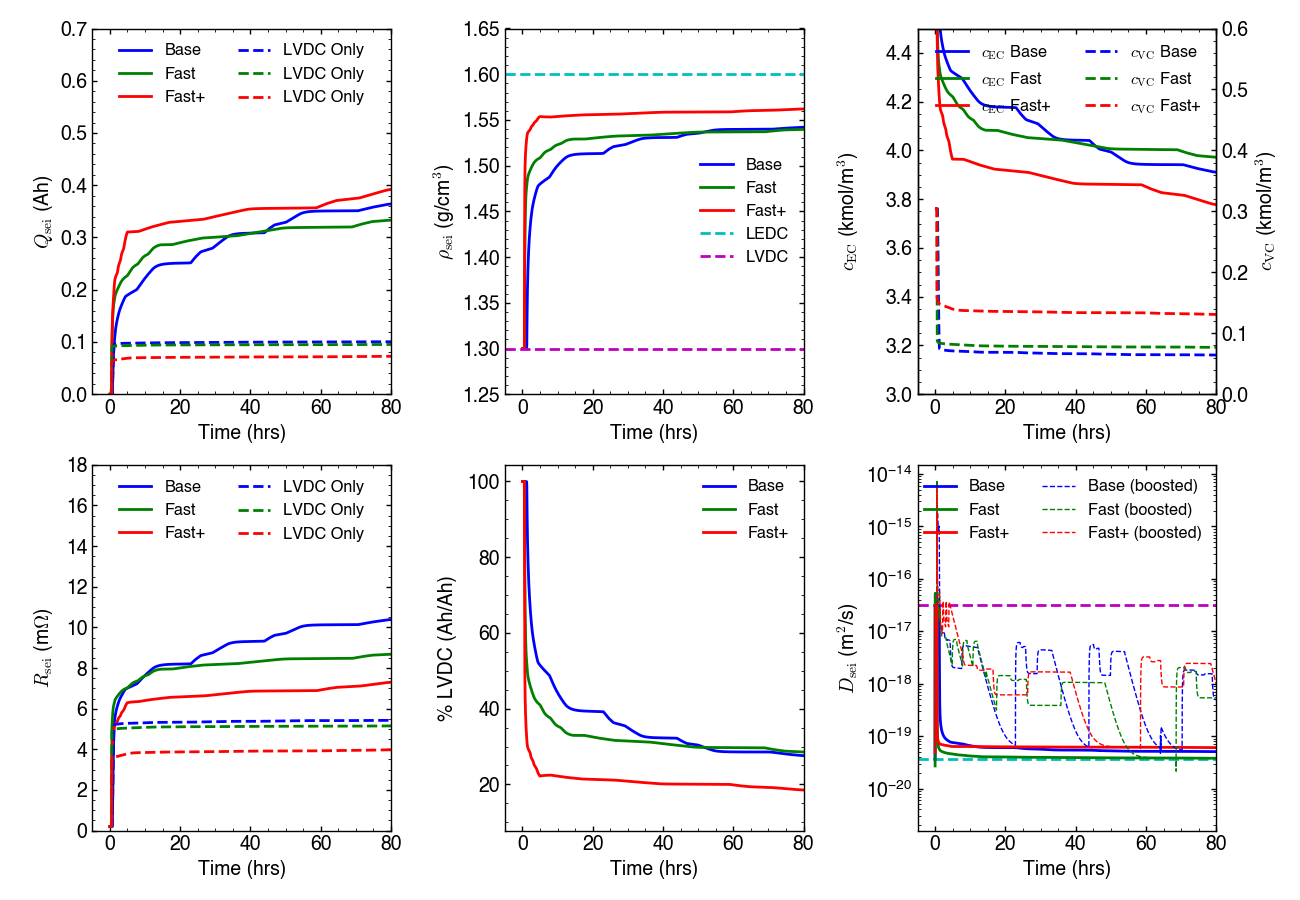

In [15]:
XMAX = 80
# XMAX = 650

fig, axs = plt.subplots(2,3, figsize=(13, 9), sharex=False)

# SEI capacity
axs[0,0].plot(df_sim1['t']/3600, df_sim1['q_sei'], color='b', ls='-', label='Base')
axs[0,0].plot(df_sim2['t']/3600, df_sim2['q_sei'], color='g', ls='-', label='Fast')
axs[0,0].plot(df_sim3['t']/3600, df_sim3['q_sei'], color='r', ls='-', label='Fast+')
axs[0,0].plot(df_sim1['t']/3600, df_sim1['q_sei2'], color='b', ls='--', label='LVDC Only')
axs[0,0].plot(df_sim2['t']/3600, df_sim2['q_sei2'], color='g', ls='--', label='LVDC Only')
axs[0,0].plot(df_sim3['t']/3600, df_sim3['q_sei2'], color='r', ls='--', label='LVDC Only')
axs[0,0].set_ylabel(r'$Q_{\mathrm{sei}}$ (Ah)')
axs[0,0].set_xlabel('Time (hrs)')
axs[0,0].set_ylim((0, 0.7))
axs[0,0].grid(False)
axs[0,0].legend(loc='upper center', ncols=2, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')
axs[0,0].set_xlim((-5,XMAX))

# SEI Resistance fraction
axs[1,0].plot(df_sim1['t']/3600, df_sim1['R_sei']*1e3, color='b', ls='-', label='Base')
axs[1,0].plot(df_sim2['t']/3600, df_sim2['R_sei']*1e3, color='g', ls='-', label='Fast')
axs[1,0].plot(df_sim3['t']/3600, df_sim3['R_sei']*1e3, color='r', ls='-', label='Fast+')
axs[1,0].plot(df_sim1['t']/3600, df_sim1['R_sei2']*1e3, color='b', ls='--', label='LVDC Only')
axs[1,0].plot(df_sim2['t']/3600, df_sim2['R_sei2']*1e3, color='g', ls='--', label='LVDC Only')
axs[1,0].plot(df_sim3['t']/3600, df_sim3['R_sei2']*1e3, color='r', ls='--', label='LVDC Only')
axs[1,0].set_ylabel(r'$R_{\mathrm{sei}}$ (m$\Omega$)')
axs[1,0].set_ylim((0, 18))
axs[1,0].set_xlabel('Time (hrs)')
axs[1,0].grid(False)
axs[1,0].legend(loc='upper center', ncols=2, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')
axs[1,0].set_xlim((-5,XMAX))

# SEI Density
axs[0,1].plot(df_sim1['t']/3600, df_sim1['rho_sei'], color='b', ls='-', label='Base')
axs[0,1].plot(df_sim2['t']/3600, df_sim2['rho_sei'], color='g', ls='-', label='Fast')
axs[0,1].plot(df_sim3['t']/3600, df_sim3['rho_sei'], color='r', ls='-', label='Fast+')
axs[0,1].axhline(rho_ec, color='c', linestyle='--', label='LEDC')
axs[0,1].axhline(rho_vc, color='m', linestyle='--', label='LVDC')
axs[0,1].set_ylabel(r'$\rho_{\mathrm{sei}}$ (g/cm$^3$)')
axs[0,1].set_xlabel('Time (hrs)')
axs[0,1].set_ylim(1.25,1.65)
axs[0,1].grid(False)
axs[0,1].legend(loc='center right', ncols=1, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')
axs[0,1].set_xlim((-5,XMAX))

# SEI LEDC fraction
axs[1,1].plot(df_sim1['t']/3600, df_sim1['q_sei2']/df_sim1['q_sei']*100, color='b', ls='-', label='Base')
axs[1,1].plot(df_sim2['t']/3600, df_sim2['q_sei2']/df_sim2['q_sei']*100, color='g', ls='-', label='Fast')
axs[1,1].plot(df_sim3['t']/3600, df_sim3['q_sei2']/df_sim3['q_sei']*100, color='r', ls='-', label='Fast+')
axs[1,1].set_ylabel(r'% LVDC (Ah/Ah)')
axs[1,1].set_xlabel('Time (hrs)')
axs[1,1].grid(False)
axs[1,1].legend(loc='upper right', ncols=1, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')
axs[1,1].set_xlim((-5,XMAX))

# Combine EC and VC concentration comparison
axs[0,2].plot(df_sim1['t']/3600, df_sim1['c_sei1']*1e-3, color='b', ls='-', label='$c_{\mathrm{EC}}$ Base')
axs[0,2].plot(df_sim2['t']/3600, df_sim2['c_sei1']*1e-3, color='g', ls='-', label='$c_{\mathrm{EC}}$ Fast')
axs[0,2].plot(df_sim3['t']/3600, df_sim3['c_sei1']*1e-3, color='r', ls='-', label='$c_{\mathrm{EC}}$ Fast+')
axs[0,2].set_ylabel('$c_{\mathrm{EC}}$ (kmol/m$^3$)')
axs[0,2].legend(loc='upper right', ncols=1, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')
axs[0,2].set_xlabel('Time (hrs)')
axs[0,2].grid(False)
axs[0,2].set_ylim(3.0, 4.5)
axs[0,2].set_xlim((-5,XMAX))
ax2 = axs[0,2].twinx()
ax2.plot(df_sim1['t']/3600, df_sim1['c_sei2']*1e-3, color='b', ls='--', label='$c_{\mathrm{VC}}$ Base')
ax2.plot(df_sim2['t']/3600, df_sim2['c_sei2']*1e-3, color='g', ls='--', label='$c_{\mathrm{VC}}$ Fast')
ax2.plot(df_sim3['t']/3600, df_sim3['c_sei2']*1e-3, color='r', ls='--', label='$c_{\mathrm{VC}}$ Fast+')
ax2.grid(False)
ax2.set_ylabel('$c_{\mathrm{VC}}$ (kmol/m$^3$)')
ax2.set_ylim(0, 0.6)

# Combine legends
lines1, labels1 = axs[0,2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axs[0,2].legend(lines1 + lines2, labels1 + labels2, loc='upper right', ncols=2, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')

axs[1,2].set_yscale('log')
axs[1,2].axhline(d_ec_opt1, color='c', linestyle='--', label='')
axs[1,2].axhline(d_vc_opt1, color='m', linestyle='--', label='')
axs[1,2].plot(df_sim1['t']/3600, df_sim1['D_sei1'], color='b', ls='-', label='Base')
axs[1,2].plot(df_sim2['t']/3600, df_sim2['D_sei1'], color='g', ls='-', label='Fast')
axs[1,2].plot(df_sim3['t']/3600, df_sim3['D_sei1'], color='r', ls='-', label='Fast+')
axs[1,2].plot(df_sim1['t']/3600, df_sim1['D_sei1']*(1+df_sim1['boost']), color='b', ls='--', label='Base (boosted)', linewidth=1)
axs[1,2].plot(df_sim2['t']/3600, df_sim2['D_sei1']*(1+df_sim2['boost']), color='g', ls='--', label='Fast (boosted)', linewidth=1)
axs[1,2].plot(df_sim3['t']/3600, df_sim3['D_sei1']*(1+df_sim3['boost']), color='r', ls='--', label='Fast+ (boosted)', linewidth=1)

axs[1,2].set_ylabel('$D_{\mathrm{sei}}$ (m$^2$/s)')
axs[1,2].legend(loc='upper right', ncols=2, fontsize='small', frameon=False, facecolor=(1,1,1,0), edgecolor='black')
axs[1,2].grid(False)
# axs[1,2].set_ylim(0, 310)
axs[1,2].set_xlabel('Time (hrs)')
axs[1,2].set_xlim((-5,XMAX))

fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

plt.savefig(f'outputs/figures/model_outputs_{XMAX}h.svg', format='svg', dpi=300)

# Manually extract the capacities from inspecting the plots

In [16]:
f1_capd1 = 2.527
f2_capd1 = 2.540
f3_capd1 = 2.536
f1_capd2 = 2.445
f2_capd2 = 2.461
f3_capd2 = 2.461
f1_capd3 = 2.275
f2_capd3 = 2.315
f3_capd3 = 2.318


# Summarize the results

In [17]:
data = {
    'Q1 [Ah]': [f1_capd1, f2_capd1, f3_capd1],
    'Q2 [Ah]': [f1_capd2, f2_capd2, f3_capd2],
    'Q3 [Ah]': [f1_capd3, f2_capd3, f3_capd3],
    'Rs [Ohms]': [np.nanmedian(Rs_estimate1), np.nanmedian(Rs_estimate3), np.nanmedian(Rs_estimate4)]
}
labels = ['Base', 'Fast', 'Fast+']

df_summary = pd.DataFrame(data, index=labels)
df_summary

NameError: name 'Rs_estimate1' is not defined

# Now take a closer look at all of the data

Including the cycling data!

In [ ]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot
axs[0].plot(df1['Timestamp'], df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(df3['Timestamp'], df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(df4['Timestamp'], df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(df1['Timestamp'], df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(df3['Timestamp'], df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(df4['Timestamp'], df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(df1['Timestamp'], df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(df3['Timestamp'], df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(df4['Timestamp'], df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(df1['Timestamp'], df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(df3['Timestamp'], df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(df4['Timestamp'], df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()


# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()


In [ ]:
PATHNAME = '/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch'

y = '152001'
file_path = f"{PATHNAME}/UMBL2022FEB_CELL{y}.pkl"


with open(file_path, 'rb') as file:
    data = pd.read_pickle(file)

print(data)

{'UMBL2022FEB_CELL152001_CAL_4P1V_P45C_5P0PSI_20230227_R1-01-007':          h_test_time  h_current  h_potential  h_step_index  h_step_time  \
0       6.043390e-02        0.0     3.401740             1     0.060434   
1       1.006168e+01        0.0     3.401740             1    10.061682   
2       2.007173e+01        0.0     3.401740             1    20.071728   
3       3.007684e+01        0.0     3.401740             1    30.076841   
4       4.007788e+01        0.0     3.401740             1    40.077882   
...              ...        ...          ...           ...          ...   
300055  7.142089e+06        0.0     3.185619            30  6409.672837   
300056  7.142099e+06        0.0     3.185619            30  6419.680903   
300057  7.142109e+06        0.0     3.185781            30  6429.694350   
300058  7.142119e+06        0.0     3.185619            30  6439.715023   
300059  7.142129e+06        0.0     3.185944            30  6449.716805   

        h_charge_capacity  h_dis